# Ejercicio 7: Generalización entre lagos

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
)

from src.config import OUT_DIR

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 7.0 Carga de datos y variables predictoras

In [2]:
df = pd.read_parquet(OUT_DIR / "ml_dataset.parquet")

UMBRAL_ALTA_CIANOBACTERIA = 10.0
df["alta_cianobacteria"] = (df["cianobacteria"] > UMBRAL_ALTA_CIANOBACTERIA).astype(int)

dia_anio = df["fecha"].dt.dayofyear
df["dia_anio_sin"] = np.sin(2 * np.pi * dia_anio / 365)
df["dia_anio_cos"] = np.cos(2 * np.pi * dia_anio / 365)
df["ndvi_x_ndwi"] = df["ndvi"] * df["ndwi"]

# Para este ejercicio se excluyen `lago` (sería constante dentro de cada set de
# entrenamiento) y las coordenadas absolutas `lat`/`lon` (Atitlán y Amatitlán ocupan
# rangos de coordenadas completamente disjuntos; usarlas implicaría extrapolar fuera
# del dominio visto en entrenamiento en lugar de evaluar generalización espectral).
NUM_FEATURES = ["green", "nir", "ndvi", "ndwi", "dia_anio_sin", "dia_anio_cos", "ndvi_x_ndwi"]
TARGET = "alta_cianobacteria"

df_atitlan = df[df["lago"] == "atitlan"].copy()
df_amatitlan = df[df["lago"] == "amatitlan"].copy()

print(f"Atitlán:   {len(df_atitlan):,} obs. | % clase positiva: {df_atitlan[TARGET].mean()*100:.2f}%")
print(f"Amatitlán: {len(df_amatitlan):,} obs. | % clase positiva: {df_amatitlan[TARGET].mean()*100:.2f}%")

Atitlán:   473,442 obs. | % clase positiva: 2.22%
Amatitlán: 65,233 obs. | % clase positiva: 44.74%


## Hiperparámetros ajustados en el Ejercicio 4

In [3]:
MODELOS_DIR = OUT_DIR / "modelos"
modelo_lr_base = joblib.load(MODELOS_DIR / "modelo_logreg.joblib")
modelo_rf_base = joblib.load(MODELOS_DIR / "modelo_rf.joblib")
modelo_xgb_base = joblib.load(MODELOS_DIR / "modelo_xgb.joblib")

C_LR = modelo_lr_base.named_steps["clf"].C

RF_PARAM_NAMES = ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
RF_PARAMS = {k: v for k, v in modelo_rf_base.named_steps["clf"].get_params().items()
             if k in RF_PARAM_NAMES}

XGB_PARAM_NAMES = ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree"]
XGB_PARAMS = {k: v for k, v in modelo_xgb_base.named_steps["clf"].get_params().items()
              if k in XGB_PARAM_NAMES}

print("Regresión Logística - C:", C_LR)
print("Random Forest -", RF_PARAMS)
print("XGBoost -", XGB_PARAMS)

Regresión Logística - C: 1
Random Forest - {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}
XGBoost - {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.9}


In [4]:
def construir_modelos(y_train):
    """Instancia los tres modelos con los hiperparámetros del Ejercicio 4, recalculando
    scale_pos_weight según el balance de clases del lago de entrenamiento."""
    n_neg, n_pos = np.bincount(y_train)
    scale_pos_weight = n_neg / n_pos

    modelo_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=C_LR, max_iter=5000, class_weight="balanced",
                                    random_state=RANDOM_STATE)),
    ])
    modelo_rf = RandomForestClassifier(**RF_PARAMS, class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)
    modelo_xgb = XGBClassifier(**XGB_PARAMS, tree_method="hist", eval_metric="aucpr",
                                scale_pos_weight=scale_pos_weight,
                                random_state=RANDOM_STATE, n_jobs=-1)

    return {"Regresión Logística": modelo_lr, "Random Forest": modelo_rf, "XGBoost": modelo_xgb}


def entrenar_y_evaluar(df_train, df_test, nombre_experimento):
    X_train, y_train = df_train[NUM_FEATURES], df_train[TARGET]
    X_test, y_test = df_test[NUM_FEATURES], df_test[TARGET]

    modelos = construir_modelos(y_train)
    predicciones = {}
    filas_metricas = []
    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        predicciones[nombre] = {"modelo": modelo, "y_test": y_test, "y_pred": y_pred, "y_proba": y_proba}

        filas_metricas.append({
            "experimento": nombre_experimento,
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "recall": recall_score(y_test, y_pred, pos_label=1),
            "f1": f1_score(y_test, y_pred, pos_label=1),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "pr_auc": average_precision_score(y_test, y_proba),
        })

    return pd.DataFrame(filas_metricas).set_index("modelo"), predicciones

## 7.1 Experimento A: entrenamiento en Atitlán, evaluación en Amatitlán

In [5]:
metricas_A, pred_A = entrenar_y_evaluar(df_atitlan, df_amatitlan, "A: Atitlán → Amatitlán")
metricas_A.round(4)

,experimento,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,
Regresión Logística,A: Atitlán → Amatitlán,0.7076,0.7493,0.5207,0.6144,0.7617,0.6476
Random Forest,A: Atitlán → Amatitlán,0.6152,0.5476,0.8040,0.6515,0.6897,0.6093
XGBoost,A: Atitlán → Amatitlán,0.6095,0.5383,0.8930,0.6717,0.7284,0.6589


## 7.2 Experimento B: entrenamiento en Amatitlán, evaluación en Atitlán

In [6]:
metricas_B, pred_B = entrenar_y_evaluar(df_amatitlan, df_atitlan, "B: Amatitlán → Atitlán")
metricas_B.round(4)

,experimento,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,
Regresión Logística,B: Amatitlán → Atitlán,0.1357,0.0243,0.9713,0.0475,0.8580,0.3553
Random Forest,B: Amatitlán → Atitlán,0.5726,0.0172,0.3260,0.0327,0.5260,0.0334
XGBoost,B: Amatitlán → Atitlán,0.5678,0.0209,0.4035,0.0397,0.5246,0.0237


## 7.3 Matrices de confusión de ambos experimentos

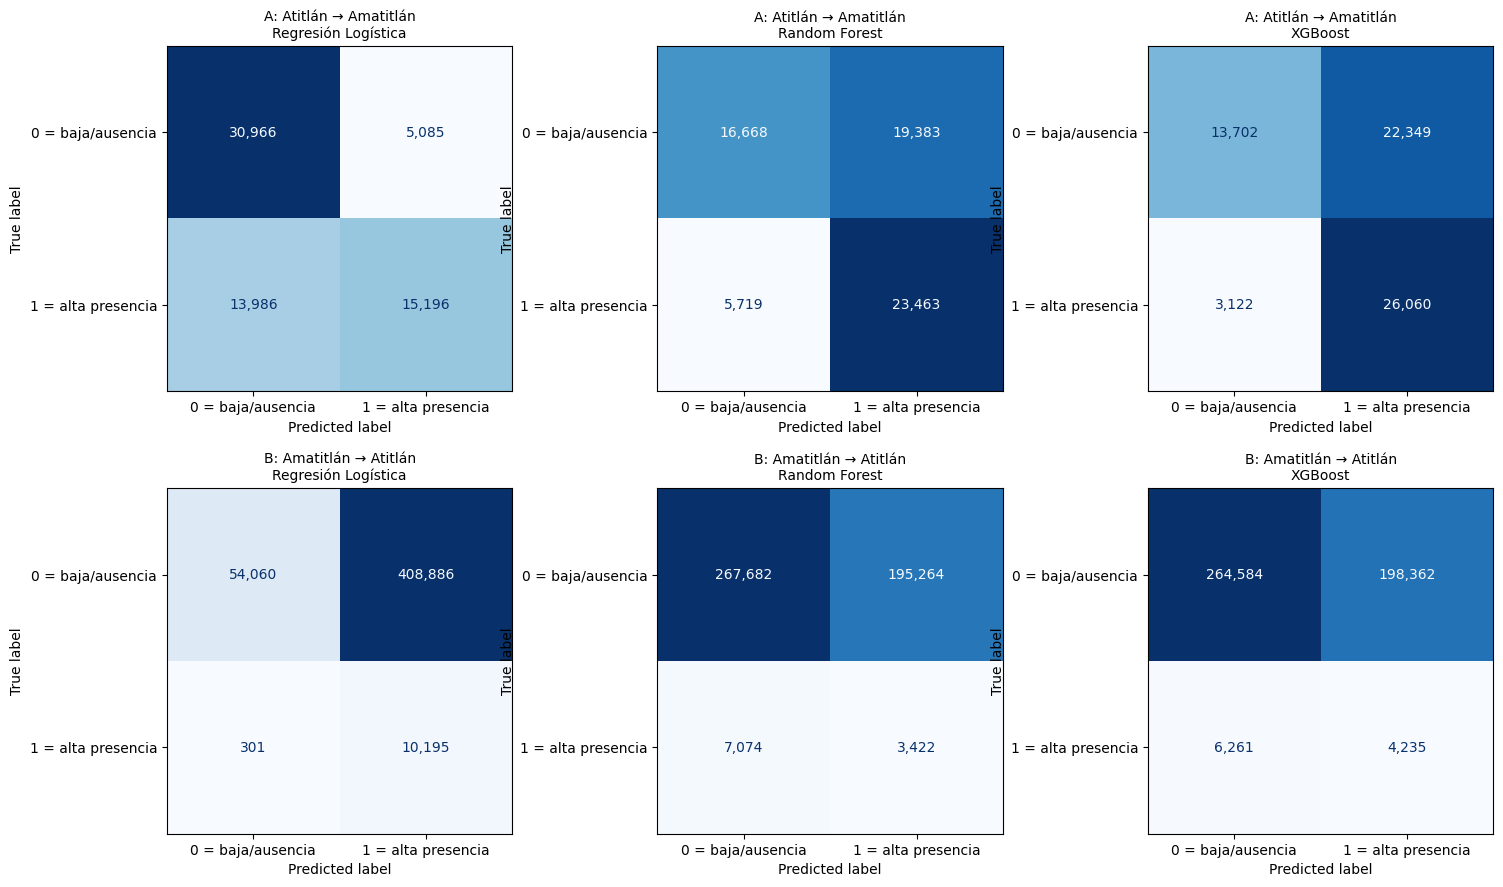

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for fila, (pred_dict, titulo_fila) in enumerate(
    [(pred_A, "A: Atitlán → Amatitlán"), (pred_B, "B: Amatitlán → Atitlán")]
):
    for ax, (nombre, pred) in zip(axes[fila], pred_dict.items()):
        cm = confusion_matrix(pred["y_test"], pred["y_pred"])
        disp = ConfusionMatrixDisplay(cm, display_labels=["0 = baja/ausencia", "1 = alta presencia"])
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
        ax.set_title(f"{titulo_fila}\n{nombre}", fontsize=10)
plt.tight_layout()
plt.show()

## 7.4 Comparación con el escenario de mismo lago (Ejercicio 5)

In [8]:
# Reconstrucción del set de prueba aleatorio del Ejercicio 5 (entrenamiento y prueba
# contienen observaciones de ambos lagos), para comparar contra los experimentos A y B.
FEATURES_MISMO_LAGO = NUM_FEATURES + ["lat", "lon", "lago"]

split_info = pd.read_parquet(OUT_DIR / "split_train_test.parquet").set_index("idx_original")
idx_test = split_info.index[split_info["particion"] == "test"]

X_test_mismo_lago = df.loc[idx_test, FEATURES_MISMO_LAGO]
y_test_mismo_lago = df.loc[idx_test, TARGET]

modelos_mismo_lago = {
    "Regresión Logística": modelo_lr_base,
    "Random Forest": modelo_rf_base,
    "XGBoost": modelo_xgb_base,
}

filas_mismo_lago = []
for nombre, modelo in modelos_mismo_lago.items():
    y_pred = modelo.predict(X_test_mismo_lago)
    y_proba = modelo.predict_proba(X_test_mismo_lago)[:, 1]
    filas_mismo_lago.append({
        "experimento": "Mismo lago (Ej. 5, ambos lagos mezclados)",
        "modelo": nombre,
        "accuracy": accuracy_score(y_test_mismo_lago, y_pred),
        "precision": precision_score(y_test_mismo_lago, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test_mismo_lago, y_pred, pos_label=1),
        "f1": f1_score(y_test_mismo_lago, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test_mismo_lago, y_proba),
        "pr_auc": average_precision_score(y_test_mismo_lago, y_proba),
    })
metricas_mismo_lago = pd.DataFrame(filas_mismo_lago).set_index("modelo")
metricas_mismo_lago.round(4)

,experimento,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,
Regresión Logística,"Mismo lago (Ej. 5, ambos lagos mezclados)",0.8943,0.4037,0.9128,0.5598,0.9548,0.6978
Random Forest,"Mismo lago (Ej. 5, ambos lagos mezclados)",0.9682,0.7358,0.8875,0.8045,0.9900,0.9180
XGBoost,"Mismo lago (Ej. 5, ambos lagos mezclados)",0.9621,0.6789,0.9209,0.7816,0.9901,0.9207


In [9]:
comparacion_generalizacion = pd.concat([
    metricas_mismo_lago.assign(experimento="Mismo lago (Ej. 5)"),
    metricas_A.assign(experimento="A: Atitlán → Amatitlán"),
    metricas_B.assign(experimento="B: Amatitlán → Atitlán"),
]).reset_index().set_index(["experimento", "modelo"]).round(4)

comparacion_generalizacion

accuracy  precision  recall  \
experimento            modelo                                             
Mismo lago (Ej. 5)     Regresión Logística    0.8943     0.4037  0.9128   
                       Random Forest          0.9682     0.7358  0.8875   
                       XGBoost                0.9621     0.6789  0.9209   
A: Atitlán → Amatitlán Regresión Logística    0.7076     0.7493  0.5207   
                       Random Forest          0.6152     0.5476  0.8040   
                       XGBoost                0.6095     0.5383  0.8930   
B: Amatitlán → Atitlán Regresión Logística    0.1357     0.0243  0.9713   
                       Random Forest          0.5726     0.0172  0.3260   
                       XGBoost                0.5678     0.0209  0.4035   

                                                f1  roc_auc  pr_auc  
experimento            modelo                                        
Mismo lago (Ej. 5)     Regresión Logística  0.5598   0.9548  0.6978  
                       Random Forest        0.8045   0.9900  0.9180  
                       XGBoost              0.7816   0.9901  0.9207  
A: Atitlán → Amatitlán Regresión Logística  0.6144   0.7617  0.6476  
                       Random Forest        0.6515   0.6897  0.6093  
                       XGBoost              0.6717   0.7284  0.6589  
B: Amatitlán → Atitlán Regresión Logística  0.0475   0.8580  0.3553  
                       Random Forest        0.0327   0.5260  0.0334  
                       XGBoost              0.0397   0.5246  0.0237

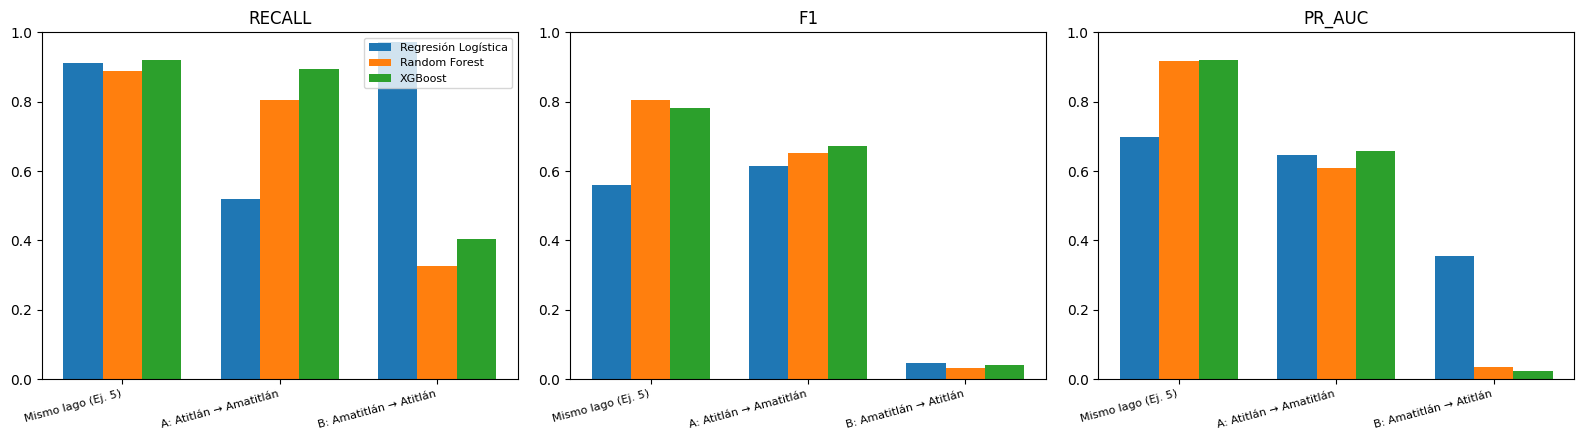

In [10]:
metricas_plot = ["recall", "f1", "pr_auc"]
experimentos = ["Mismo lago (Ej. 5)", "A: Atitlán → Amatitlán", "B: Amatitlán → Atitlán"]
modelos_nombres = ["Regresión Logística", "Random Forest", "XGBoost"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(experimentos))
ancho = 0.25

for ax, metrica in zip(axes, metricas_plot):
    for i, modelo in enumerate(modelos_nombres):
        valores = [comparacion_generalizacion.loc[(exp, modelo), metrica] for exp in experimentos]
        ax.bar(x + (i - 1) * ancho, valores, width=ancho, label=modelo)
    ax.set_xticks(x)
    ax.set_xticklabels(experimentos, rotation=15, ha="right", fontsize=8)
    ax.set_title(metrica.upper())
    ax.set_ylim(0, 1)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7.5 ¿Un modelo entrenado en un lago puede generalizar adecuadamente al otro?

_(interpretación pendiente)_

## 7.6 Discusión: diferencias geográficas, ambientales o espectrales entre lagos

In [11]:
# Insumo de apoyo para la discusión 7.6: distribución de las variables predictoras
# espectrales/temporales por lago, para contrastar los dominios de entrenamiento.
df.groupby("lago", observed=True)[NUM_FEATURES + ["cianobacteria"]].describe().T

lago                    amatitlan        atitlan
green         count  65233.000000  473442.000000
              mean       0.072256       0.055643
              std        0.110989       0.168358
              min        0.002500       0.004500
              25%        0.021100       0.014600
...                           ...            ...
cianobacteria min      -19.164131     -19.991730
              25%        5.175627       2.862839
              50%        8.691021       3.993094
              75%       17.204502       4.498233
              max      149.560532     149.939636

[64 rows x 2 columns]

_(interpretación pendiente)_